In [1]:
import wrds
import pandas as pd
import numpy as np

In [41]:
inst_data = pd.read_csv('stress_volatility_institutional_data2.csv')

In [37]:
# Convert date columns to datetime (because we need to filter by quarter)
inst_data['date'] = pd.to_datetime(inst_data['date'])

# Create quarter variable.
inst_data['quarter'] = inst_data['date'].dt.to_period('Q')

In [38]:
#filter out small holdings (<.1% cutoff)
# Remove missing ownership observations
inst_data = inst_data.dropna(subset=['ownership_pct'])

inst_data = inst_data[inst_data['ownership_pct'] >= 0.001]

In [32]:
# ownership network by quarter

all_overlap_results = []

for q in inst_data['quarter'].unique():
    
    quarter_data = inst_data[inst_data['quarter'] == q]
    
    # Skip quarters with fewer than 2 firms
    if quarter_data['ticker'].nunique() < 2:
        continue
    
    # Remove duplicate firm–institution pairs
    quarter_data = quarter_data.drop_duplicates(
        subset=['ticker','mgrno']
    )

    # Build firm × institution matrix
    # Rows = firms
    # Columns = institutions
    # Values = ownership percentage
    
    firm_inst_matrix = quarter_data.pivot_table(
        index='ticker',
        columns='mgrno',
        values='ownership_pct',
        fill_value=0
    )
    
    # Convert to numpy array
    W = firm_inst_matrix.values
    
    # Compute weighted firm–firm overlap matrix
    # A = W W'
   
    
    overlap_matrix = W @ W.T
    
    overlap_df = pd.DataFrame(
        overlap_matrix,
        index=firm_inst_matrix.index,
        columns=firm_inst_matrix.index
    )
    
    # Remove self-overlap (diagonal = 0)
    np.fill_diagonal(overlap_df.values, 0)
    
    
    # Convert matrix to long format (AI assisntance needed here)
    
    overlap_long = pd.DataFrame({
        'firm_i': np.repeat(overlap_df.index.values, len(overlap_df.columns)),
        'firm_j': np.tile(overlap_df.columns.values, len(overlap_df.index)),
        'ownership_overlap': overlap_df.values.flatten()
    })
    
    # Remove self-pairs and zero-overlap pairs
    overlap_long = overlap_long[
        (overlap_long['firm_i'] != overlap_long['firm_j']) &
        (overlap_long['ownership_overlap'] > 0)
    ]
    
    # Add quarter identifier
    overlap_long['quarter'] = q
    
    all_overlap_results.append(overlap_long)



In [33]:
ownership_network = pd.concat(all_overlap_results, ignore_index=True)

print("Ownership network constructed successfully.")
print("Total observations:", len(ownership_network))
print(ownership_network.head())

Ownership network constructed successfully.
Total observations: 3440
  firm_i firm_j  ownership_overlap quarter
0   AAPL   AMZN           0.011207  2018Q1
1   AAPL   ASML           0.005577  2018Q1
2   AAPL    BAC           0.014646  2018Q1
3   AAPL   GOOG           0.011653  2018Q1
4   AAPL    JNJ           0.013237  2018Q1


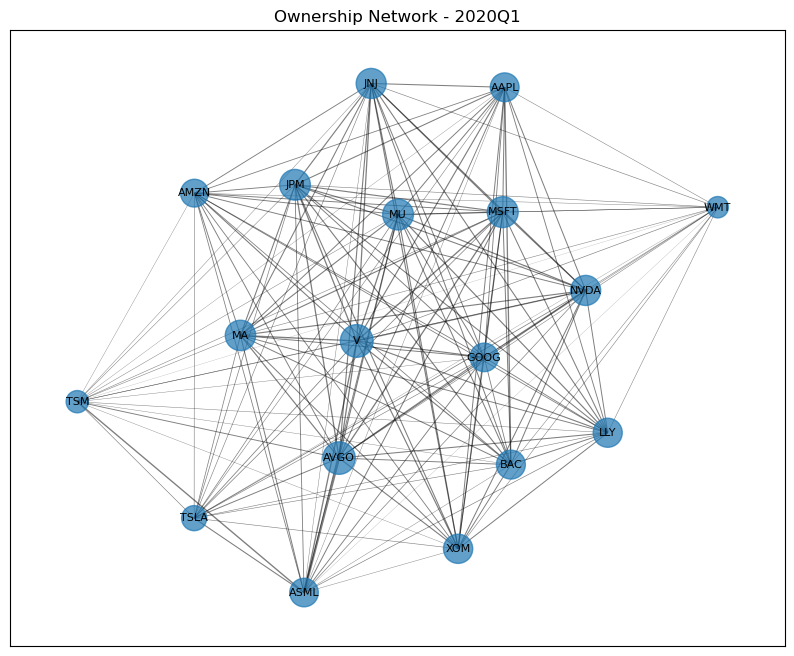

In [34]:
#vizualize network where Nodes = firms, Node size = weighted degree centrality, Edge thickness = ownership_overlap
import networkx as nx
import matplotlib.pyplot as plt

# Choose one representative quarter  out of 11 (chose 2020Q1)
q = '2020Q1'

q_data = ownership_network[ownership_network['quarter'] == q]

# Build graph
G = nx.Graph()

for _, row in q_data.iterrows():
    G.add_edge(row['firm_i'], row['firm_j'],
               weight=row['ownership_overlap'])

# Compute weighted degree centrality
centrality = dict(G.degree(weight='weight'))

# Draw
plt.figure(figsize=(10,8))
pos = nx.spring_layout(G, seed=1)

nx.draw_networkx_nodes(
    G, pos,
    node_size=[centrality[n]*2000 for n in G.nodes()],
    alpha=0.7
)

nx.draw_networkx_edges(
    G, pos,
    width=[G[u][v]['weight']*50 for u,v in G.edges()],
    alpha=0.5
)

nx.draw_networkx_labels(G, pos, font_size=8)
plt.title(f'Ownership Network - {q}')
plt.show()

In [ ]:
#compute correlations

inst_data['date'] = pd.to_datetime(inst_data['date'])
inst_data['quarter'] = inst_data['date'].dt.to_period('Q')

all_corr_results = []

for q in inst_data['quarter'].unique():
    
    q_data = inst_data[inst_data['quarter'] == q]
    
    # Need enough days to compute correlation
    if q_data['date'].nunique() < 5:
        continue
    
    # Pivot to date × firm matrix
    ret_matrix = q_data.pivot_table(
        index='date',
        columns='ticker',
        values='daily_returns'  # change if column name differs
    )
    
    # Compute correlation matrix
    corr_matrix = ret_matrix.corr()
    
    # Convert to long format
    corr_long = pd.DataFrame({
        'firm_i': np.repeat(corr_matrix.index.values, len(corr_matrix.columns)),
        'firm_j': np.tile(corr_matrix.columns.values, len(corr_matrix.index)),
        'stress_correlation': corr_matrix.values.flatten()
    })
    
    # Remove self-correlations
    corr_long = corr_long[corr_long['firm_i'] != corr_long['firm_j']]
    
    corr_long['quarter'] = q
    
    all_corr_results.append(corr_long)

stress_corr_df = pd.concat(all_corr_results, ignore_index=True)

print(stress_corr_df.head())

  firm_i firm_j  stress_correlation quarter
0   AAPL   AMZN            0.710758  2018Q1
1   AAPL   ASML            0.588411  2018Q1
2   AAPL   AVGO            0.668191  2018Q1
3   AAPL    BAC            0.782746  2018Q1
4   AAPL   GOOG            0.699523  2018Q1


In [45]:
#merge with ownership network
final_analysis = ownership_network.merge(
    stress_corr_df,
    on=['firm_i','firm_j','quarter'],
    how='inner'
)

print(final_analysis.head())

  firm_i firm_j  ownership_overlap quarter  stress_correlation
0   AAPL   AMZN           0.011207  2018Q1            0.710758
1   AAPL   ASML           0.005577  2018Q1            0.588411
2   AAPL    BAC           0.014646  2018Q1            0.782746
3   AAPL   GOOG           0.011653  2018Q1            0.699523
4   AAPL    JNJ           0.013237  2018Q1            0.596514


In [46]:
#regression
import statsmodels.api as sm

X = sm.add_constant(final_analysis['ownership_overlap'])
y = final_analysis['stress_correlation']

model = sm.OLS(y, X).fit()
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:     stress_correlation   R-squared:                       0.027
Model:                            OLS   Adj. R-squared:                  0.026
Method:                 Least Squares   F-statistic:                     85.54
Date:                Fri, 27 Feb 2026   Prob (F-statistic):           4.09e-20
Time:                        20:12:38   Log-Likelihood:                -884.40
No. Observations:                3134   AIC:                             1773.
Df Residuals:                    3132   BIC:                             1785.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                        coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------
const                 0.3901      0.01

Stocks that share greater institutional ownership exhibit significantly higher return correlations during market stress periods. The estimated coefficient on ownership overlap is 12.46 (t = 9.25, p < 0.001), implying that a 1 percent increase in ownership overlap is associated with roughly a 0.125 increase in stress period correlation. While the model explains about 2.7% of the variation in pairwise correlations (R² = 0.027), the effect is economically meaningful and consistent with the hypothesis that shared institutional investors amplify comovement during market stress.

The histogram shows that most pairwise correlations during stress are strongly positive, with a concentration between roughly 0.4 and 0.9 and a mean around 0.39 (the regression constant). This confirms that market stress is associated with elevated comovement overall, and that ownership overlap explains variation around this already high baseline level of correlation.

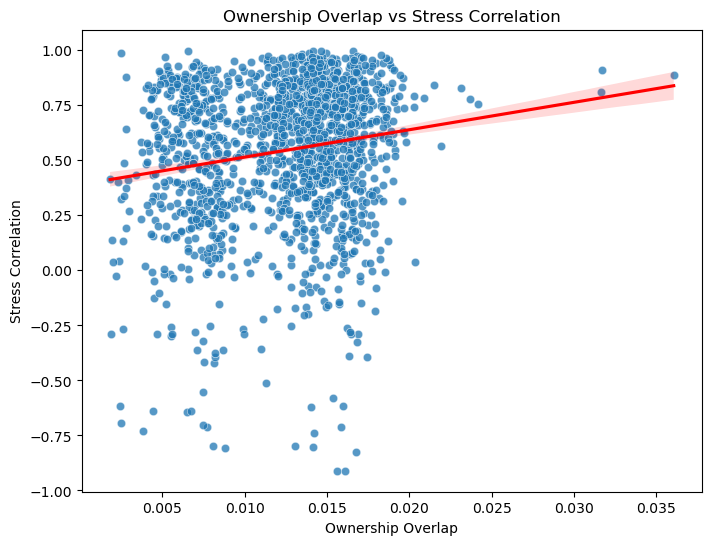

In [ ]:
#vizualize in scatterplot Ownership Overlap vs Stress Correlation
plt.figure(figsize=(8,6))

sns.scatterplot(
    x='ownership_overlap',
    y='stress_correlation',
    data=final_analysis,
    alpha=0.5
)

sns.regplot(
    x='ownership_overlap',
    y='stress_correlation',
    data=final_analysis,
    scatter=False,
    color='red'
)

plt.title('Ownership Overlap vs Stress Correlation')
plt.xlabel('Ownership Overlap')
plt.ylabel('Stress Correlation')

plt.show()

The scatter plot shows a clear positive relationship between ownership overlap and stress-period correlation, with the fitted regression line sloping upward. However, there is substantial dispersion in correlations at lower levels of overlap, but the overall trend indicates that firm pairs with greater shared institutional ownership tend to show stronger comovement during stress, consistent with the estimated coefficient of 12.46.